In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('web_page_data.csv')

In [3]:
df.head()

,Page,Time
0,Page A,0.21
1,Page B,2.53
2,Page A,0.35
3,Page B,0.71
4,Page A,0.67


In [4]:
# Converting time to seconds

df['Seconds'] = df['Time'] * 100
df.head()

,Page,Time,Seconds
0,Page A,0.21,21.0
1,Page B,2.53,253.0
2,Page A,0.35,35.0
3,Page B,0.71,71.0
4,Page A,0.67,67.0


In [5]:
df.describe()

,Time,Seconds
count,36.000000,36.000000
mean,1.411944,141.194444
std,0.942407,94.240670
min,0.210000,21.000000
25%,0.702500,70.250000
50%,1.180000,118.000000
75%,1.992500,199.250000
max,3.570000,357.000000


In [6]:
df.isna().sum()

Page       0
Time       0
Seconds    0
dtype: int64

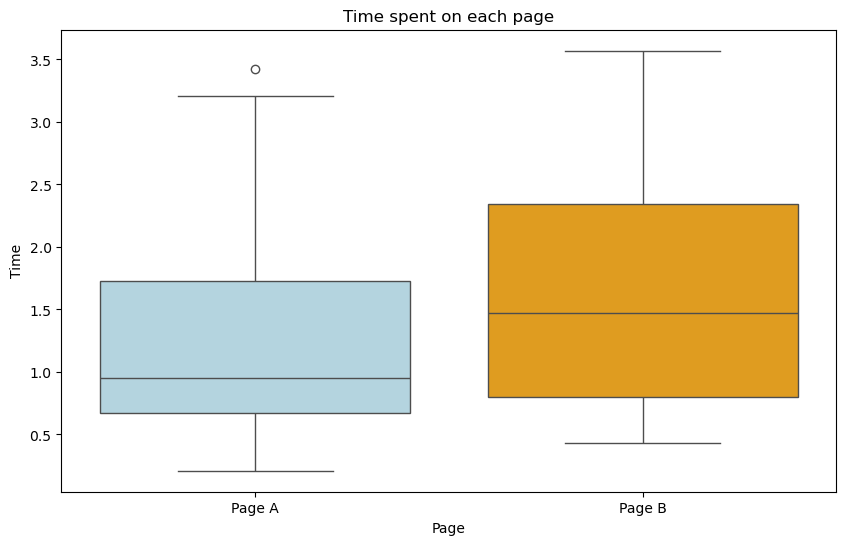

In [7]:
# Box plot visualizing distribution of time

plt.figure(figsize = (10, 6))
sns.boxplot(x = 'Page', y = 'Time', data = df, hue = 'Page', palette = {"Page A" : "lightblue", "Page B" : "orange"})
plt.title('Time spent on each page')
plt.show()

In [8]:
Page_A = df[df['Page'] == 'Page A']['Seconds']
Page_B = df[df['Page'] == 'Page B']['Seconds']

In [9]:
# Normality test using Shapiro-Wilk test

def normality(page, data):
    stat, p_value = stats.shapiro(data)
    print(f"{page}: p-value = {p_value:.4f}")
    if p_value < 0.05:
        print("Null hypothesis rejected : Data is not normally distributed.\n")
    else:
        print("Failed to reject null hypothesis : Data is normally distributed.\n")

normality("Page A", Page_A)
normality("Page B", Page_B)

Page A: p-value = 0.0175
Null hypothesis rejected : Data is not normally distributed.

Page B: p-value = 0.1612
Failed to reject null hypothesis : Data is normally distributed.



In [13]:
# Checking variance using Levene's test

test_stat_var, p_value_var = stats.levene(Page_A, Page_B)
print("p value:%.4f" % p_value_var)
    
if p_value_var < 0.05:
    print("Null hypothesis rejected : Variances of the samples are different.")
else:
    print("Failed to reject null hypothesis : Variances of the samples are same.")

p value:0.4725
Failed to reject null hypothesis : Variances of the samples are same.


In [11]:
# Mann-Whitney U test to check statistical significant difference b/w the groups

u_stat, p_value = stats.mannwhitneyu(Page_A, Page_B, alternative='two-sided')

print("U-Statistic: %.4f" % u_stat)
print("P-Value: %.4f" % p_value)

# Interpret the results

if p_value < 0.05:
    print("There is a statistically significant difference.")
else:
    print("There is no statistically significant difference.")

U-Statistic: 119.5000
P-Value: 0.2288
There is no statistically significant difference.
